## 1 - Model 3 Neural Network
While tree-based ensemble models such as Random Forest are widely regarded as strong baselines for intrusion detection on NSL-KDD, neural networks remain an important complementary modeling family. Prior studies show that Multi-Layer Perceptrons (MLPs) and related neural architectures are capable of capturing complex non-linear relationships between network traffic features and attack patterns, particularly when interactions between attributes are subtle or highly overlapping (Abrar et al., 2020; Hong et al., 2021; Rawat & Srinivasan, 2019; Hegde et al., 2024).

However, the literature also emphasizes that neural networks do not automatically outperform classical machine-learning methods on NSL-KDD. Their performance is highly sensitive to preprocessing choices, feature scaling, class imbalance, architecture design, and regularization. In several comparative studies, such as Abrar et al. (2020), Hong et al. (2021), and Hegde et al. (2024),neural networks achieve competitive results but are often matched or surpassed by tree-based ensembles in terms of accuracy, robustness, and interpretability. As a result, neural networks are best viewed not as a guaranteed upgrade, but as a more expressive alternative whose benefits must be empirically validated.

Hence, the purpose of introducing a neural network is therefore focused on empirical validation rather than assumed superiority. After establishing strong baselines with logistic regression and Random Forest, the neural network serves as a controlled experiment to assess whether additional representational capacity translates into measurable gains on NSL-KDD, particularly in the multi-class setting. 

Main objectives of this model are to:
* Assess whether a non-linear, fully connected neural network can improve multi-class detection performance compared to linear models and tree-based ensembles
* Evaluate the sensitivity of neural networks to feature scaling, class imbalance, and label distribution in NSL-KDD
* Compare predictive performance using standard metrics (accuracy, macro-F1, per-class recall) under the same data splits used for previous models
* Analyze training dynamics (loss curves, convergence behavior) to identify overfitting or underfitting tendencies
* Position neural networks fairly within the overall modeling pipeline, without assuming superiority over simpler or more interpretable methods


## 1 - Packages

In [2]:
# Start by importing all required libs...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score
from utils import load_split
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

All packages loaded successfully.


## 2 - Loading data

In [3]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [4]:
# #Scale input data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled   = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# # Integers to one-hot vectors
# y_train_multi = to_categorical(y_train, num_classes=40)
# y_val_multi   = to_categorical(y_val, num_classes=40)
# y_test_multi = to_categorical(y_test, num_classes=40)

# # Map Class 16 to 0, all other to 1
# y_train_bin = np.where(y_train == 16, 0, 1)
# y_val_bin   = np.where(y_val == 16, 0, 1)
# y_test_bin = np.where(y_test == 16, 0, 1)

# # Multiclass to binary
# y_binary = np.where(y_train == 16, 0, 1)
# print("Class counts:")
# print(pd.Series(y_binary).value_counts())
# # You should now see only 0s and 1s

# PV: alternative option in line with previous models (reuse encoder)
y_encoder = joblib.load("data/processed/label_encoder.joblib")
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

y_train_bin = (y_train != normal_id).astype(int)
y_val_bin   = (y_val   != normal_id).astype(int)
y_test_bin  = (y_test  != normal_id).astype(int)

print(pd.Series(y_train_bin).value_counts())

num_classes = len(np.unique(y_train))
print("X_train dtype:", X_train.dtype)
print("Any NaN in X_train:", np.isnan(X_train).any())
print("Any Inf in X_train:", np.isinf(X_train).any())
print("X_train min/max:", np.min(X_train), np.max(X_train))
print("y_train dtype:", y_train.dtype)
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("unique classes:", len(np.unique(y_train)))
print("expected num_classes:", num_classes)
print("any negative labels:", (y_train < 0).any())
print("any labels >= num_classes:", (y_train >= num_classes).any())
print("any labels >= 40:", (y_train >= 40).any())
print("max label:", y_train.max())

Normal class:  16
0    53874
1    46904
Name: count, dtype: int64
X_train dtype: float64
Any NaN in X_train: False
Any Inf in X_train: False
X_train min/max: -2.595417049293426 354.9253442627055
y_train dtype: int64
y_train min: 1
y_train max: 35
unique classes: 23
expected num_classes: 23
any negative labels: False
any labels >= num_classes: True
any labels >= 40: False
max label: 35


c:\Users\marti\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 4 - Multi-classification

### 4.1 – Training model 3MCv1: Multiclass neural network

This model applies a feed-forward neural network to the multi-class NSL-KDD intrusion detection task. The network consists of two fully connected hidden layers with ReLU activations and a softmax output layer, enabling it to learn non-linear relationships between features and attack classes. Class labels are kept as integer-encoded targets and optimized using sparse categorical cross-entropy, which is mathematically equivalent to one-hot encoding with categorical cross-entropy while simplifying preprocessing and reducing memory overhead. Dropout regularisation is applied after each hidden layer to mitigate overfitting by randomly deactivating a fraction of neurons during training, encouraging more robust feature representations and improved generalisation.


In [5]:
input_shape = (X_train.shape[1],) 
num_classes = len(y_encoder.classes_) # not hard coded num_classes = 40
print("--- Building Model 3MCv1 ---")
# Build Model 1 (Neural network with 20 training cycles, no early stopping)
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', # instead of categorical_crossentropy
                metrics=['accuracy'])

# Train
print("Training  Model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val)
)

--- Building Model 3MCv1 ---
Training  Model 3MCv1...


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9581 - loss: 0.1770 - val_accuracy: 0.9882 - val_loss: 0.0448
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9828 - loss: 0.0593 - val_accuracy: 0.9899 - val_loss: 0.0354
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9865 - loss: 0.0466 - val_accuracy: 0.9913 - val_loss: 0.0302
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9877 - loss: 0.0416 - val_accuracy: 0.9921 - val_loss: 0.0278
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9891 - loss: 0.0391 - val_accuracy: 0.9921 - val_loss: 0.0276
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9897 - loss: 0.0345 - val_accuracy: 0.9928 - val_loss: 0.0250
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9898 - loss: 0.0334 - val_accuracy: 0.9934 - val_loss: 0.0246
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9905 - loss: 0.0311 - 

### 4.2 - Prediction and accuracy Model 3MCv1

In [6]:
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
# y_true_integers = np.argmax(y_test, axis=1)

print("--- Classification Report 3MCv1 ---")

report = classification_report(y_test, y_pred_3MCv1, output_dict=True)
print(classification_report(y_test, y_pred_3MCv1))  

705/705 - 1s - 801us/step - accuracy: 0.7091 - loss: 16.6995

Test Accuracy: 70.91%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step
--- Classification Report 3MCv1 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       1.00      0.83      0.91       359
           2       0.71      0.50      0.59        20
           3       1.00      0.33      0.50         3
           4       1.00      0.01      0.02      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.75      0.98      0.85       141
           8       0.50      1.00      0.67         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94   

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

Although Model 3MCv1 achieved high validation accuracy during training, its test performance reveals a strong dependence on majority classes. While overall accuracy reaches approximately 71%, the macro-averaged F1-score remains low (+/- 0.25), indicating poor recall for rare attack categories. This highlights the limitations of standard neural networks on highly imbalanced intrusion-detection datasets such as NSL-KDD and confirms that accuracy alone is insufficient for evaluating multi-class intrusion detection performance.

### 4.3 - Training model 3MCv2: Neural network with L1 regularisation with early stopping mechanism

In [11]:
print("--- Building Model 3MCv2 (L1 Regularized) ---")

model_3MCv2 = Sequential([
    Dense(128, activation='relu', 
                 input_shape=input_shape,
                 kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv2.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

print("Starting training...")
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_3MCv2 = model_3MCv2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


--- Building Model 3MCv2 (L1 Regularized) ---
Starting training...
Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9510 - loss: 0.3818 - val_accuracy: 0.9824 - val_loss: 0.1483
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9764 - loss: 0.1564 - val_accuracy: 0.9845 - val_loss: 0.1208
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9804 - loss: 0.1290 - val_accuracy: 0.9870 - val_loss: 0.1060
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9819 - loss: 0.1187 - val_accuracy: 0.9891 - val_loss: 0.0935
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9832 - loss: 0.1104 - val_accuracy: 0.9886 - val_loss: 0.0921
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9832 - loss: 0.1084 - val_accuracy: 0.9868 - val_loss: 0.0887
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9836 - loss: 0.1050 - val_accuracy: 0.9859 - val_loss: 0.0863
Epoch 8/50
1575/1575 ━━

### 4.4 - Prediction and accuracy Model 3MCv2

In [14]:
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)

print("--- Classification Report 3MCv2 ---")
report = classification_report(y_test, y_pred_3MCv2, output_dict=True)
print(classification_report(y_test, y_pred_3MCv2))

705/705 - 1s - 762us/step - accuracy: 0.7102 - loss: 5.6581

Test Accuracy: 71.02%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step
--- Classification Report 3MCv2 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.97      0.97      0.97       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.82      0.97      0.89       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.93    

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 4.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

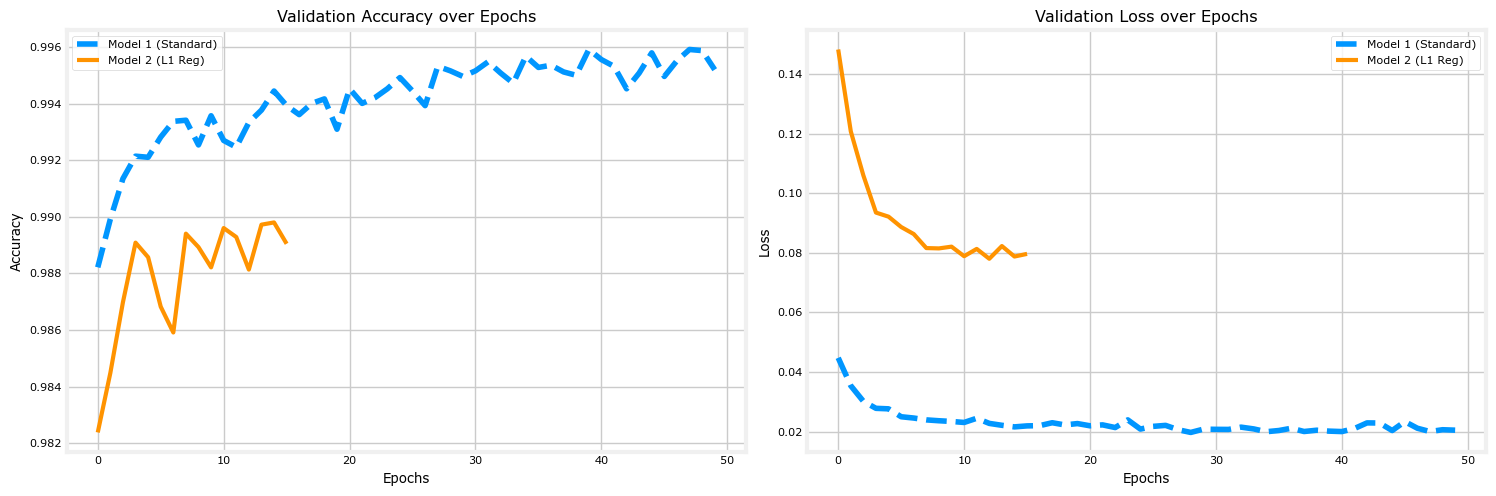

--- Final Project Results ---
          Metric Model 3MCv1 (Standard) Model 3MCv2 (L1 Regularized)
0  Test Accuracy                 70.91%                       71.02%
1  Features Used         All 41 (Dense)     All 41 (Sparse/Filtered)


In [15]:
plt.close('all') 
# Create a clean figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Validation Accuracy Comparison
ax1.plot(history_3MCv1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
ax1.plot(history_3MCv2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
ax1.set_title('Validation Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Comparison
ax2.plot(history_3MCv1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
ax2.plot(history_3MCv2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
ax2.set_title('Validation Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout() 
plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3MCv1 (Standard)": [f"{test_acc_3MCv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3MCv2 (L1 Regularized)": [f"{test_acc_3MCv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)

## 5 - Binary classification

### 5.1 - Training model 3BINv1: Neural network with 20 training cycles and no regularisation 

In [18]:
print("--- Building Model 3BINv1 ---")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Training  Model 3BINv1...")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    verbose=1
)

--- Building Model 3BINv1 ---
Training  Model 3BINv1...
Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9742 - loss: 0.0724 - val_accuracy: 0.9883 - val_loss: 0.0313
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0365 - val_accuracy: 0.9910 - val_loss: 0.0254
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9895 - loss: 0.0306 - val_accuracy: 0.9925 - val_loss: 0.0215
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0269 - val_accuracy: 0.9929 - val_loss: 0.0212
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0244 - val_accuracy: 0.9938 - val_loss: 0.0198
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.9935 - val_loss: 0.0183
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9924 - loss: 0.0212 - val_accuracy: 0.9938 - val_loss: 0.0178
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━

### 5.2 Prediction and accuracy Model 3BINv1

In [19]:
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test)

y_pred_3BINv1 = (y_pred_3BINv1_probs > 0.5).astype("int32")

print("--- Classification Report 3MCv1 ---")
print(classification_report(y_test_bin, y_pred_3BINv1, target_names=['Normal', 'Attack']))


705/705 - 1s - 1ms/step - accuracy: 0.7851 - loss: 2.7697
Test Accuracy: 78.51%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step
--- Classification Report 3MCv1 ---
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.80      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.79      0.78     22544



### 5.3 Training model 3BINv2: Neural network with L1 regularisation with early stopping mechanism

In [20]:
model_bin_3BINv2 = Sequential([
    Dense(128, activation='relu', 
          input_shape=input_shape,
          kernel_regularizer=tf.keras.regularizers.l1(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv2.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

early_stopping_bin = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training 3BINv2...")
history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)

Training 3BINv2...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9720 - loss: 0.1897 - val_accuracy: 0.9886 - val_loss: 0.0786
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9845 - loss: 0.0810 - val_accuracy: 0.9866 - val_loss: 0.0678
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9853 - loss: 0.0746 - val_accuracy: 0.9904 - val_loss: 0.0596
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9859 - loss: 0.0686 - val_accuracy: 0.9909 - val_loss: 0.0549
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9860 - loss: 0.0669 - val_accuracy: 0.9905 - val_loss: 0.0534
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9869 - loss: 0.0631 - val_accuracy: 0.9896 - val_loss: 0.0548
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9860 - loss: 0.0636 - val_accuracy: 0.9892 - val_loss: 0.0574
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9869 - loss: 0.0625 - val_accurac

### 5.4 Prediction and accuracy Model 3BINv2

In [21]:
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test Accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test)

y_pred_3BINv2 = (y_pred_3BINv2_probs > 0.5).astype("int32")

print("--- Classification Report 3BINv2 ---")
print(classification_report(y_test_bin, y_pred_3BINv2, target_names=['Normal', 'Attack']))

705/705 - 1s - 999us/step - accuracy: 0.7828 - loss: 0.9891
Test Accuracy: 78.28%
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step
--- Classification Report 3BINv2 ---
              precision    recall  f1-score   support

      Normal       0.67      0.98      0.79      9711
      Attack       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.81      0.78     22544
weighted avg       0.84      0.78      0.78     22544



### 5.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

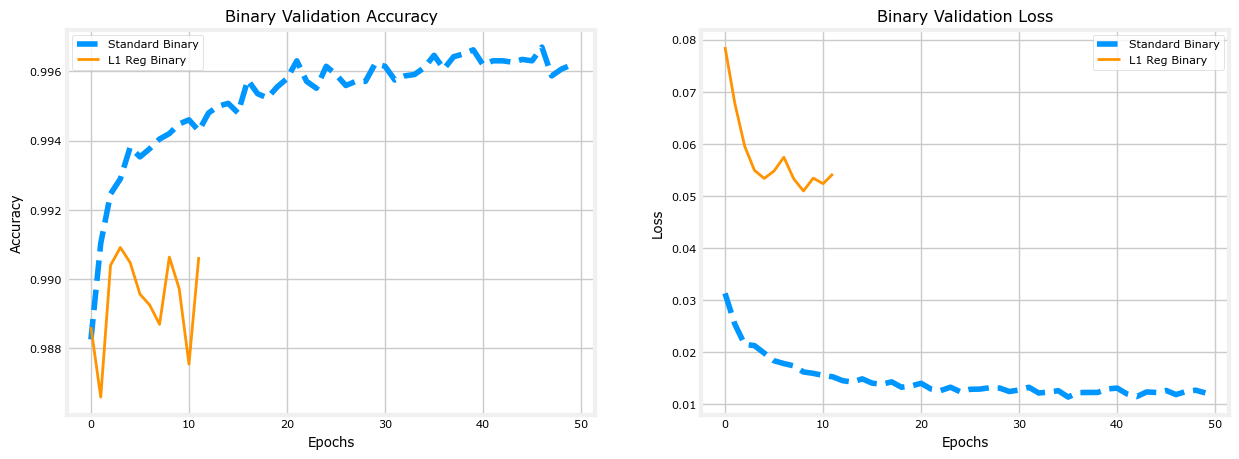

--- Final Project Results ---
          Metric Model 3BINv1 (Standard) Model 3BINv2 (L1 Regularized)
0  Test Accuracy                  78.51%                        78.28%
1  Features Used          All 41 (Dense)      All 41 (Sparse/Filtered)


In [22]:
plt.close('all') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(history_bin_3BINv1.history['val_accuracy'], label='Standard Binary', linestyle='--')
ax1.plot(history_bin_3BINv2.history['val_accuracy'], label='L1 Reg Binary', linewidth=2)
ax1.set_title('Binary Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history_bin_3BINv1.history['val_loss'], label='Standard Binary', linestyle='--')
ax2.plot(history_bin_3BINv2.history['val_loss'], label='L1 Reg Binary', linewidth=2)
ax2.set_title('Binary Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3BINv1 (Standard)": [f"{test_acc_3BINv1*100:.2f}%", "All 41 (Dense)"],
    "Model 3BINv2 (L1 Regularized)": [f"{test_acc_3BINv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)


## 6 - Visualisation

### 6.1 Visualisation multi-classification

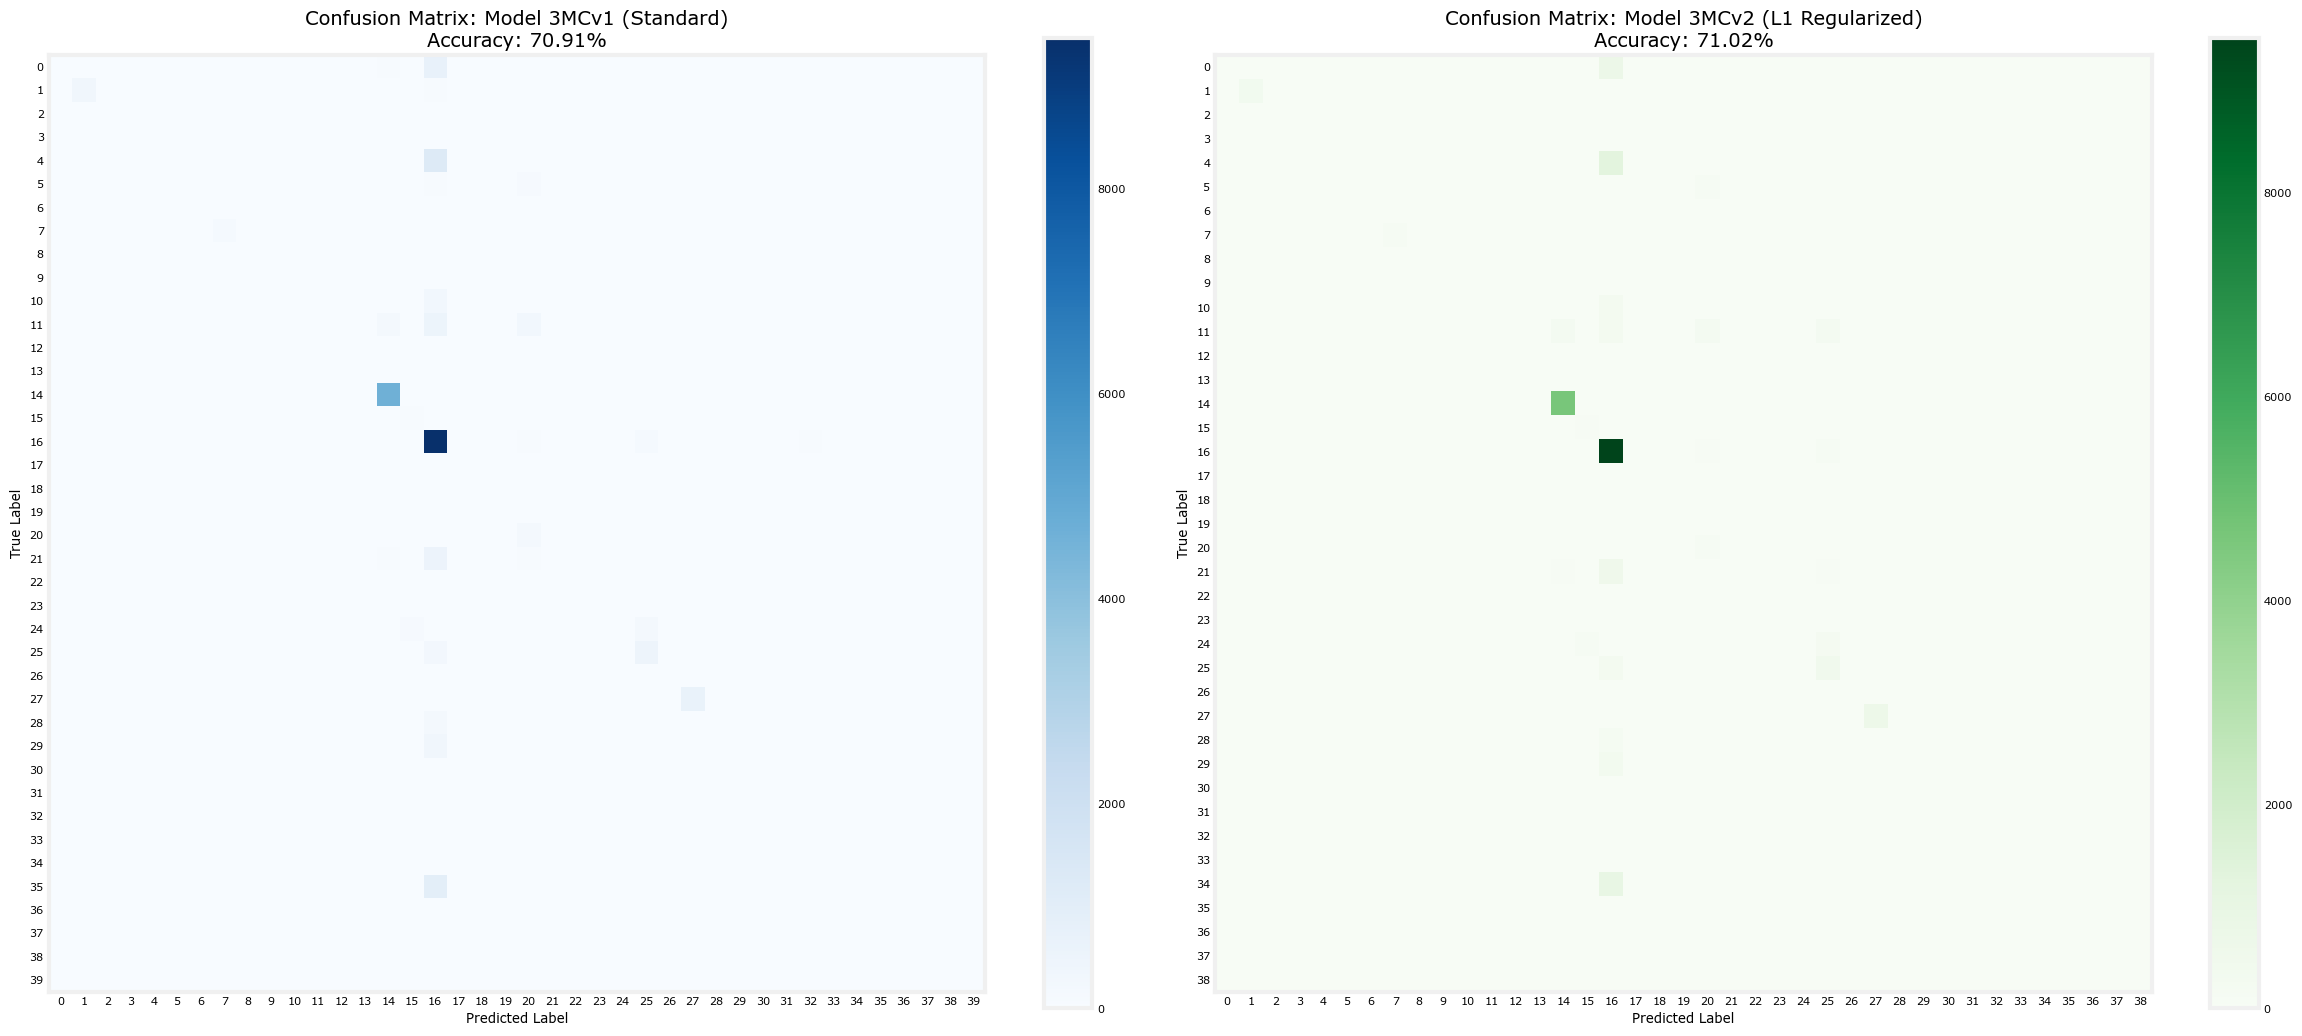

In [25]:
plt.close('all') 
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot voor Model 3MCv1

cm1 = confusion_matrix(y_test, y_pred_3MCv1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot(ax=axes[0], cmap='Blues', include_values=False, colorbar=True)
axes[0].set_title(f"Confusion Matrix: Model 3MCv1 (Standard)\nAccuracy: {test_acc_3MCv1:.2%}", fontsize=14)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot voor Model 3MCv2 
cm2 = confusion_matrix(y_test, y_pred_3MCv2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot(ax=axes[1], cmap='Greens', include_values=False, colorbar=True)
axes[1].set_title(f"Confusion Matrix: Model 3MCv2 (L1 Regularized)\nAccuracy: {test_acc_3MCv2:.2%}", fontsize=14)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### 6.2 Visualisation and optimalisation binary classification

--- Visualizing Model 3BINv1 (Standard) ---
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step


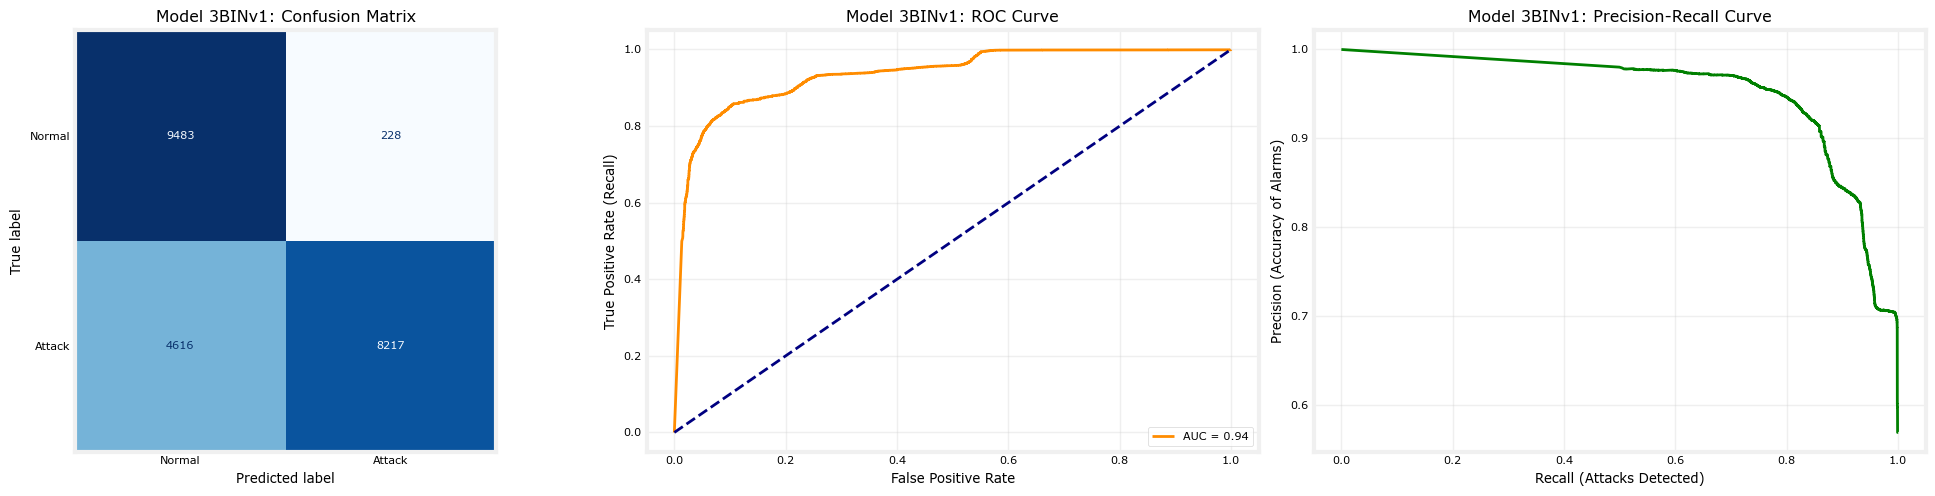


--- Visualizing Model 3BINv2 (L1 Regularized) ---
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step


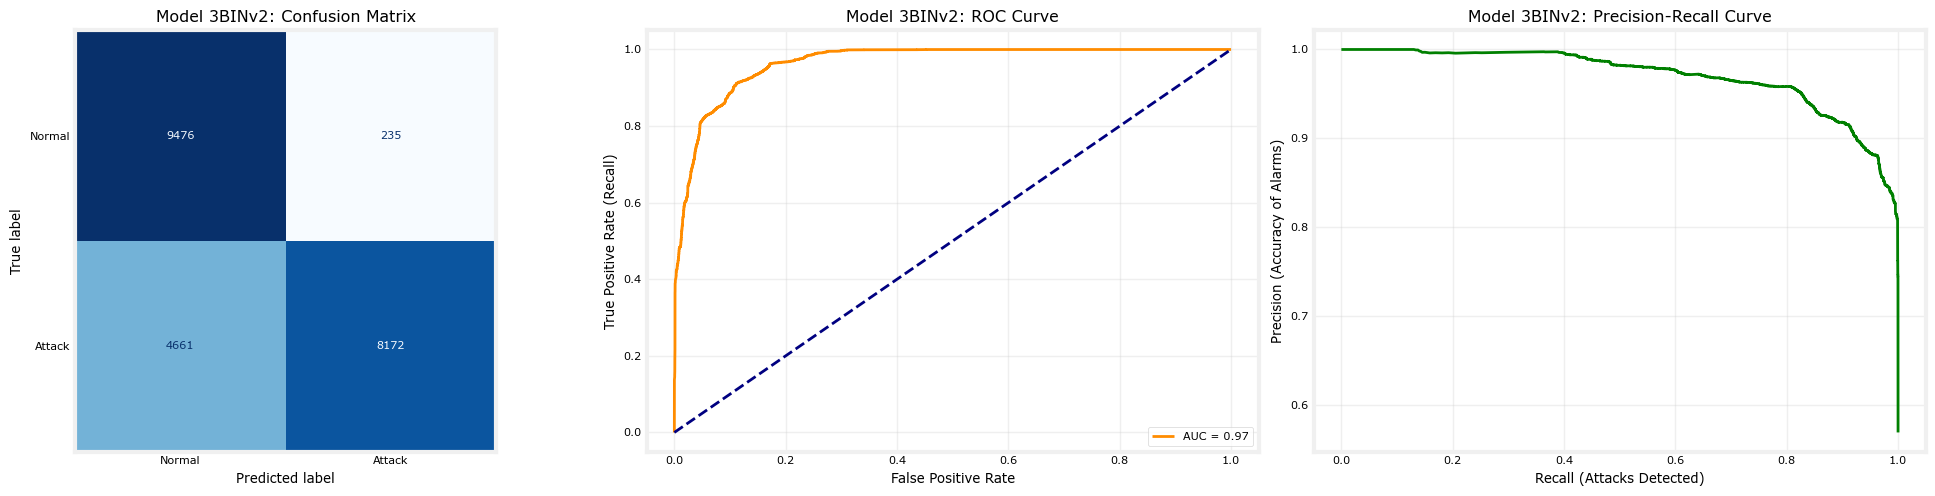

In [27]:
def plot_performance_visuals(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
    axes[0].set_title(f'{model_name}: Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].set_title(f'{model_name}: ROC Curve')
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2)
    axes[2].set_xlabel('Recall (Attacks Detected)')
    axes[2].set_ylabel('Precision (Accuracy of Alarms)')
    axes[2].set_title(f'{model_name}: Precision-Recall Curve')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("--- Visualizing Model 3BINv1 (Standard) ---")
plot_performance_visuals(model_bin_3BINv1, X_test, y_test_bin, "Model 3BINv1")

print("\n--- Visualizing Model 3BINv2 (L1 Regularized) ---")
plot_performance_visuals(model_bin_3BINv2, X_test, y_test_bin, "Model 3BINv2")

In [28]:
def find_optimal_threshold(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"\n--- {model_name} Optimization ---")
    print(f"Optimal Threshold: {best_threshold:.2f} | Best F1 Score: {best_f1:.2f}")
    return best_threshold

thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_test, y_test_bin, "Model 3BINv1")
thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_test, y_test_bin, "Model 3BINv2")

y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test).ravel() > thresh_v1).astype(int)
y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test).ravel() > thresh_v2).astype(int)

print(f"\n=== Final Report: Model 3BINv1 (Threshold {thresh_v1:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v1) * 100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v1, target_names=['Normal', 'Attack']))

print(f"\n=== Final Report: Model 3BINv2 (Threshold {thresh_v2:.2f}) ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v2) * 100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v2, target_names=['Normal', 'Attack']))

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step

--- Model 3BINv1 Optimization ---
Optimal Threshold: 0.01 | Best F1 Score: 0.84
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step

--- Model 3BINv2 Optimization ---
Optimal Threshold: 0.01 | Best F1 Score: 0.89
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step

=== Final Report: Model 3BINv1 (Threshold 0.01) ===
Accuracy: 84.10%
              precision    recall  f1-score   support

      Normal       0.75      0.96      0.84      9711
      Attack       0.96      0.75      0.84     12833

    accuracy                           0.84     22544
   macro avg       0.85      0.85      0.84     22544
weighted avg       0.87      0.84      0.84     22544


=== Final Report: Model 3BINv2 (Threshold 0.01) ===
Accuracy: 88.14%
              precision    recall  f1-score   support

      Normal       0.83      0.91      0.87      9711
      Attack       0.93      0.86      0.89     12833

    accuracy                       

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step


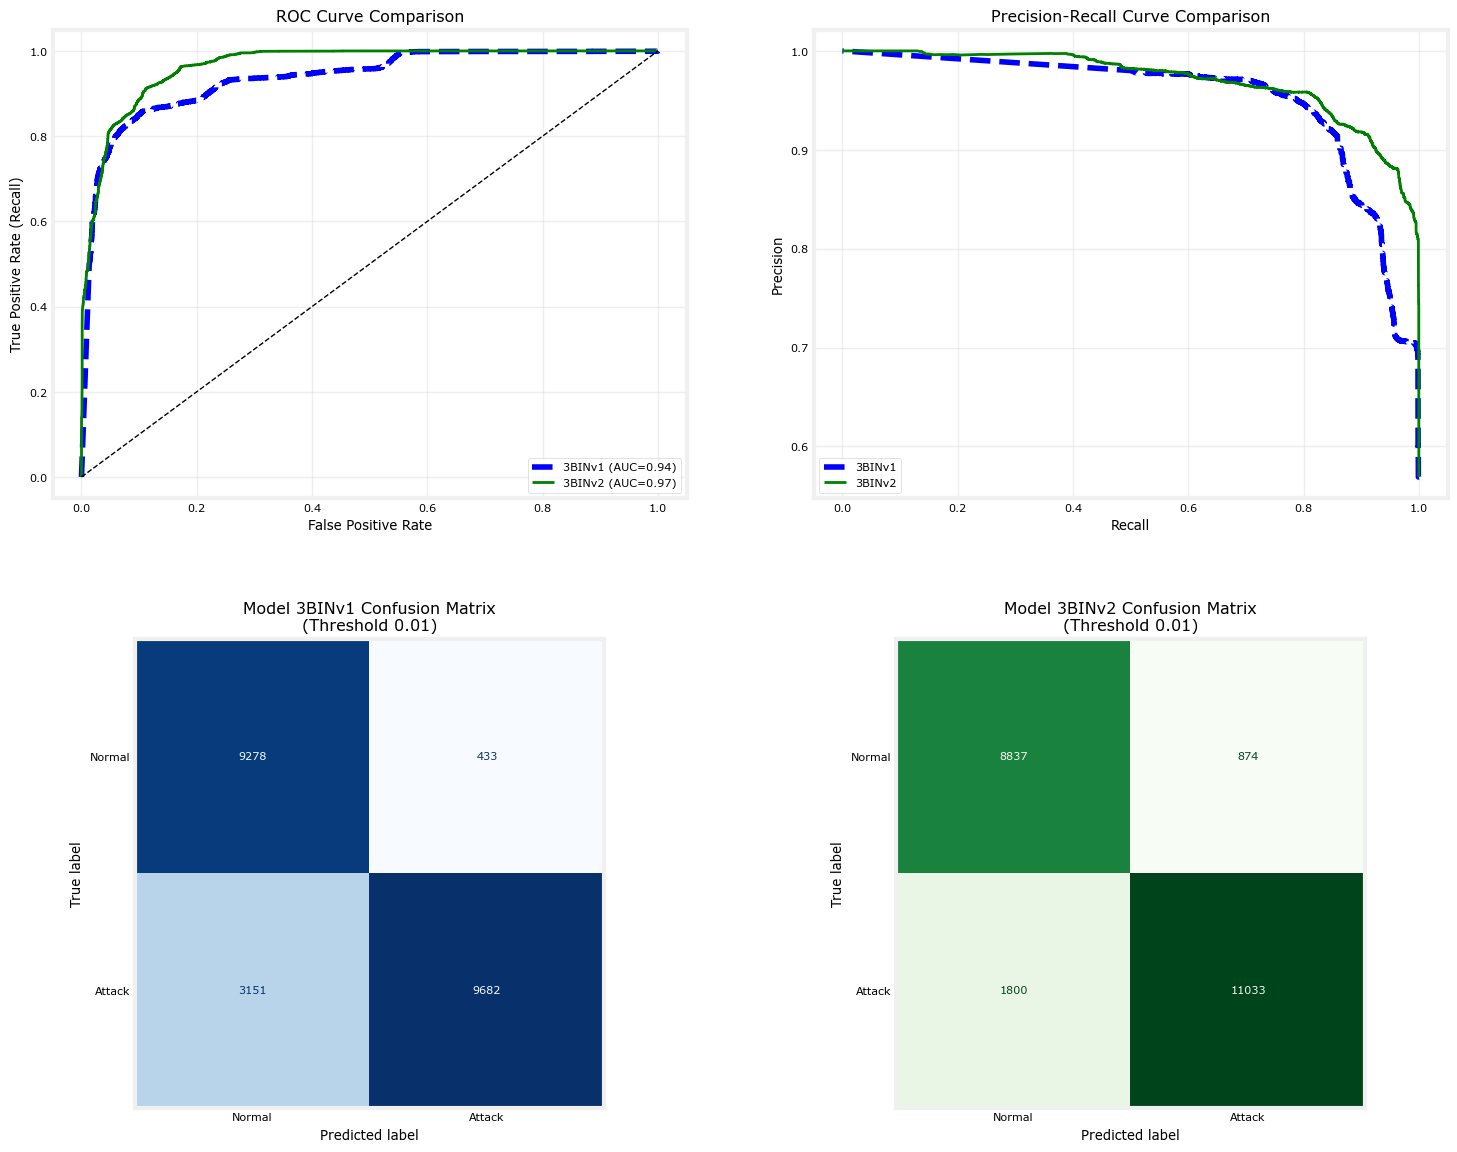

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

y_prob_v1 = model_bin_3BINv1.predict(X_test).ravel()
y_prob_v2 = model_bin_3BINv2.predict(X_test).ravel()

t1 = locals().get('thresh_v1', 0.01)
t2 = locals().get('thresh_v2', 0.01)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# Top Left: ROC Comparison
fpr1, tpr1, _ = roc_curve(y_test_bin, y_prob_v1)
fpr2, tpr2, _ = roc_curve(y_test_bin, y_prob_v2)
axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue', label=f'3BINv1 (AUC={auc(fpr1, tpr1):.2f})')
axes[0, 0].plot(fpr2, tpr2, linewidth=2, color='green', label=f'3BINv2 (AUC={auc(fpr2, tpr2):.2f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC Curve Comparison')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Top Right: Precision-Recall Comparison
p1, r1, _ = precision_recall_curve(y_test_bin, y_prob_v1)
p2, r2, _ = precision_recall_curve(y_test_bin, y_prob_v2)
axes[0, 1].plot(r1, p1, linestyle='--', color='blue', label='3BINv1')
axes[0, 1].plot(r2, p2, linewidth=2, color='green', label='3BINv2')
axes[0, 1].set_title('Precision-Recall Curve Comparison')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Bottom Left: Confusion Matrix 3BINv1
cm_v1 = confusion_matrix(y_test_bin, (y_prob_v1 > t1).astype(int))
disp_v1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=['Normal', 'Attack'])
disp_v1.plot(cmap='Blues', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Model 3BINv1 Confusion Matrix\n(Threshold {t1:.2f})')

# Bottom Right: Confusion Matrix 3BINv2
cm_v2 = confusion_matrix(y_test_bin, (y_prob_v2 > t2).astype(int))
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Normal', 'Attack'])
disp_v2.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Model 3BINv2 Confusion Matrix\n(Threshold {t2:.2f})')

plt.show()